### Seasalt AOD and profiles

Read GEOS-Chem `GEOSChem.Aerosols.20190601_0000z.nc4` and plot:
1. **Total AOD map** — column tau_ref = sum of layer AOD at 550 nm (tropospheric aerosol species).
2. **Sea-salt column AOD** (SALA + SALC) and a few **open-ocean vertical profiles** of layer AOD and wet radius.

In [ ]:
from pathlib import Path

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

NC_PATH = Path("/home/zhe2/data/MyProjects/PACE_redSIF_PACE/GEOSChem.Aerosols.20190601_0000z.nc4")
OUT_DIR = Path("/home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Layer AOD species that make up tropospheric tau_ref at 550 nm.
# AODDust already equals the sum of AODDust550nm_bin1..7, so use AODDust once.
AOD_SPECIES = [
    "AODHyg550nm_SO4",
    "AODHyg550nm_SALA",
    "AODHyg550nm_SALC",
    "AODHyg550nm_OCPI",
    "AODHyg550nm_BCPI",
    "AODDust",
    "AODSOAfromAqIsoprene550nm",
]
SEASALT_AOD = ["AODHyg550nm_SALA", "AODHyg550nm_SALC"]

ds = nc.Dataset(NC_PATH)
lat = np.asarray(ds["lat"][:], dtype=float)
lon = np.asarray(ds["lon"][:], dtype=float)
lev = np.asarray(ds["lev"][:], dtype=float)
hyam = np.asarray(ds["hyam"][:], dtype=float)  # hPa
hybm = np.asarray(ds["hybm"][:], dtype=float)
P0 = float(ds["P0"][:])  # hPa
# Approximate mid-layer pressure with surface ~ P0 (hybrid sigma).
p_mid = hyam + hybm * P0

layer_aod = {name: np.asarray(ds[name][0], dtype=float) for name in AOD_SPECIES}  # (lev, lat, lon)
tau_layer = np.sum([layer_aod[n] for n in AOD_SPECIES], axis=0)
tau_ref = np.sum(tau_layer, axis=0)  # column = sum over layers

sala = np.asarray(ds["AODHyg550nm_SALA"][0], dtype=float)
salc = np.asarray(ds["AODHyg550nm_SALC"][0], dtype=float)
ss_layer = sala + salc
ss_col = np.sum(ss_layer, axis=0)

r_ssa = np.asarray(ds["Chem_WetAeroRadiSSA"][0], dtype=float) * 1e4  # cm -> um
r_ssc = np.asarray(ds["Chem_WetAeroRadiSSC"][0], dtype=float) * 1e4

ds.close()
print(f"Grid: {len(lon)} lon x {len(lat)} lat x {len(lev)} lev")
print(f"tau_ref range: {np.nanmin(tau_ref):.3f} .. {np.nanmax(tau_ref):.3f}")
print(f"seasalt column AOD range: {np.nanmin(ss_col):.3f} .. {np.nanmax(ss_col):.3f}")

Grid: 72 lon x 46 lat x 72 lev
tau_ref range: 0.007 .. 0.700
seasalt column AOD range: 0.000 .. 0.296


Wrote /home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/geoschem_total_aod_map.png


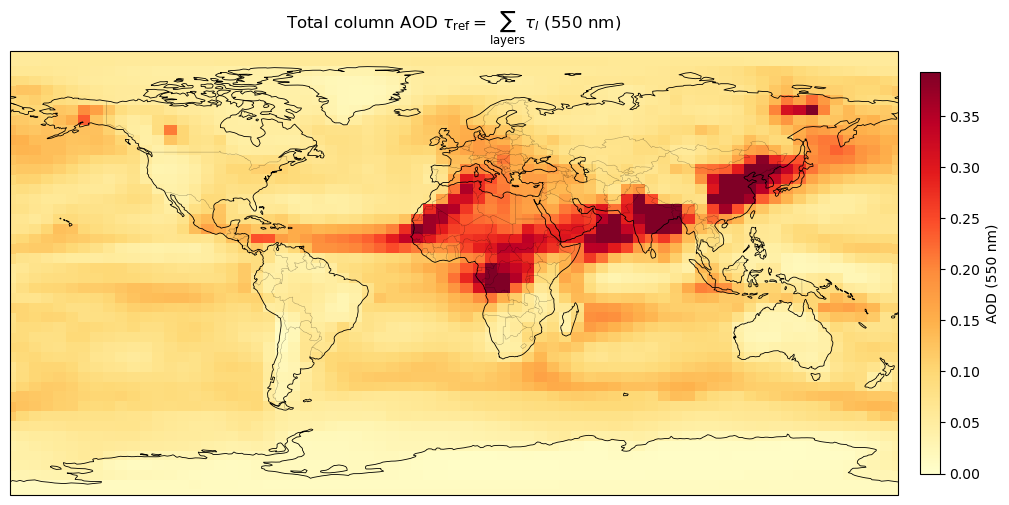

Wrote /home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/geoschem_seasalt_aod_map.png


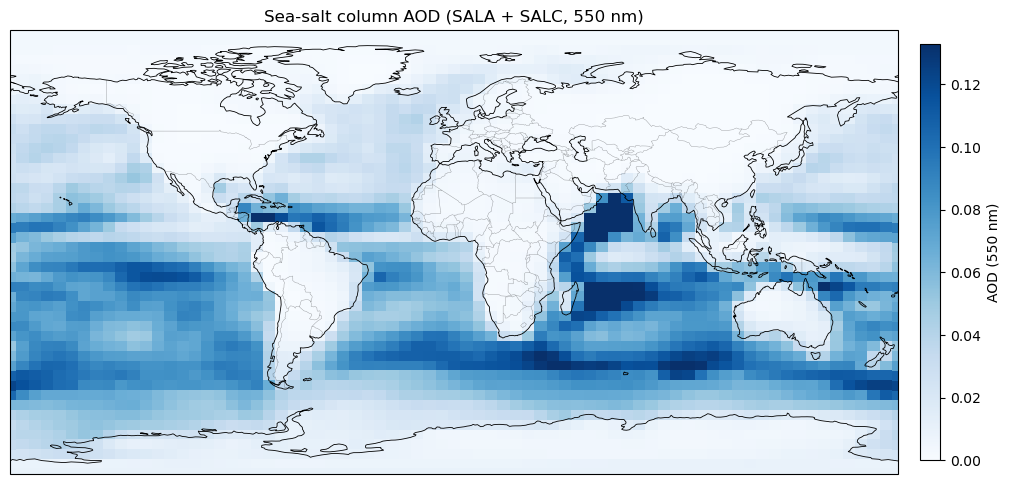

In [2]:
def plot_aod_map(field, title, fname, vmax=None, cmap="YlOrRd"):
    fig = plt.figure(figsize=(11, 5.2))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    Lon, Lat = np.meshgrid(lon, lat)
    pcm = ax.pcolormesh(
        Lon, Lat, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        shading="auto",
        vmin=0.0,
        vmax=vmax if vmax is not None else np.nanpercentile(field, 99),
    )
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.4)
    ax.set_global()
    ax.set_title(title)
    cb = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
    cb.set_label("AOD (550 nm)")
    fig.tight_layout()
    out = OUT_DIR / fname
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print("Wrote", out)
    plt.show()

plot_aod_map(
    tau_ref,
    r"Total column AOD $\tau_\mathrm{ref}=\sum_\mathrm{layers}\tau_l$ (550 nm)",
    "geoschem_total_aod_map.png",
)
plot_aod_map(
    ss_col,
    "Sea-salt column AOD (SALA + SALC, 550 nm)",
    "geoschem_seasalt_aod_map.png",
    cmap="Blues",
)

Wrote /home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/geoschem_seasalt_fraction_map.png
ratio range: 0.000 .. 0.942  median=0.512


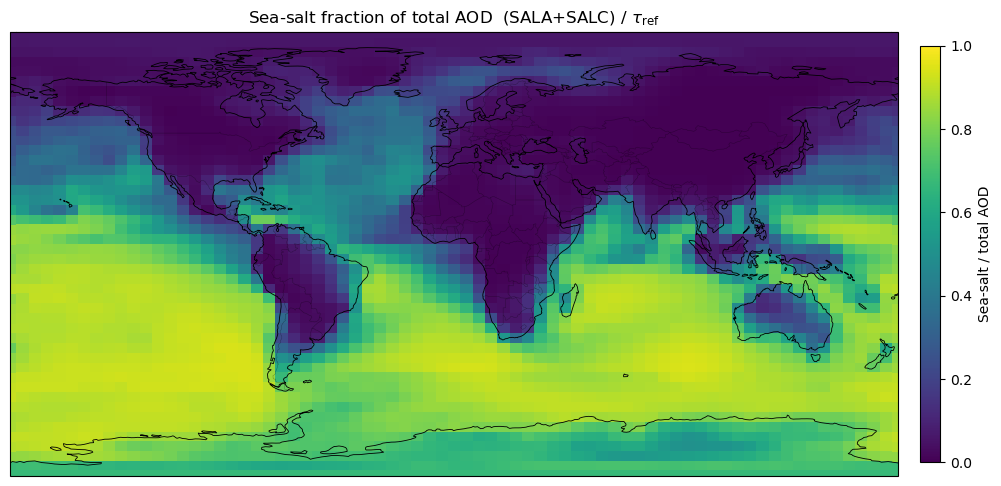

In [4]:
# ratio of sea salt to total aod
ratio = np.divide(ss_col, tau_ref, out=np.full_like(ss_col, np.nan), where=tau_ref > 0)

fig = plt.figure(figsize=(11, 5.2))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
Lon, Lat = np.meshgrid(lon, lat)
pcm = ax.pcolormesh(
    Lon, Lat, ratio,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    shading="auto",
    vmin=0.0,
    vmax=1.0,
)
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.4)
ax.set_global()
ax.set_title(r"Sea-salt fraction of total AOD  (SALA+SALC) / $\tau_{\mathrm{ref}}$")
cb = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
cb.set_label("Sea-salt / total AOD")
fig.tight_layout()
out = OUT_DIR / "geoschem_seasalt_fraction_map.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Wrote", out)
print(f"ratio range: {np.nanmin(ratio):.3f} .. {np.nanmax(ratio):.3f}  median={np.nanmedian(ratio):.3f}")
plt.show()

Wrote /home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/geoschem_seasalt_profiles.png


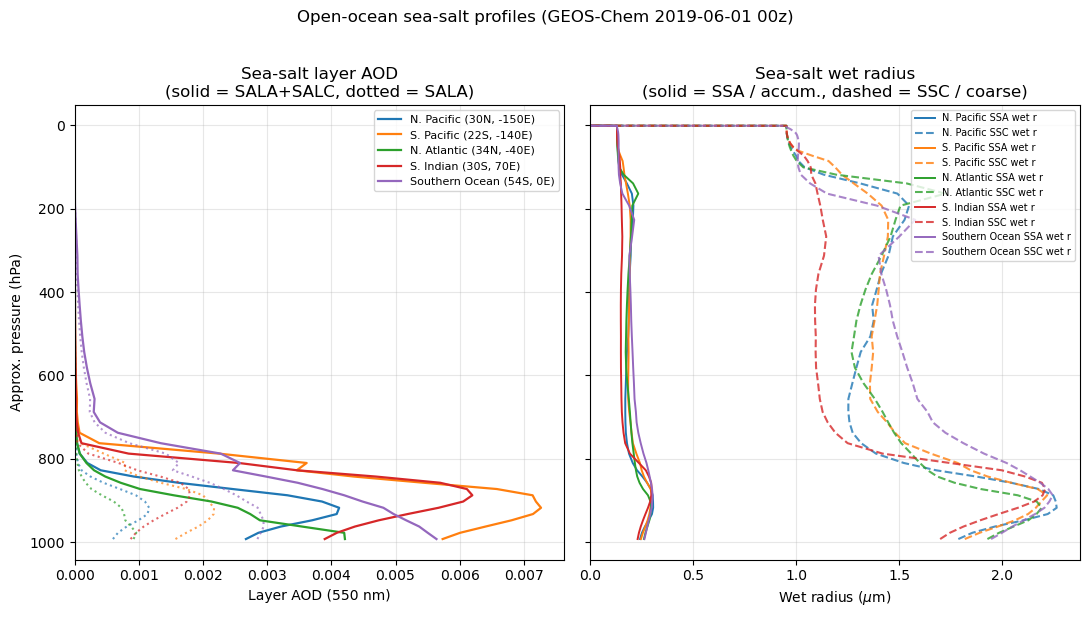

site                    lat     lon  tau_ref   SS AOD     SALA     SALC
N. Pacific             30.0  -150.0    0.069    0.034    0.009    0.025
S. Pacific            -22.0  -140.0    0.089    0.080    0.022    0.058
N. Atlantic            34.0   -40.0    0.067    0.027    0.007    0.020
S. Indian             -30.0    70.0    0.075    0.064    0.017    0.046
Southern Ocean        -54.0     0.0    0.070    0.062    0.036    0.026


In [3]:
# Open-ocean sites (defined here so this cell runs without depending on a prior map cell).
SITES = [
    ("N. Pacific", 30.0, -150.0),
    ("S. Pacific", -20.0, -140.0),
    ("N. Atlantic", 35.0, -40.0),
    ("S. Indian", -30.0, 70.0),
    ("Southern Ocean", -55.0, 0.0),
]

def nearest_ij(lat0, lon0):
    i = int(np.argmin(np.abs(lat - lat0)))
    j = int(np.argmin(np.abs(lon - lon0)))
    return i, j

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

for name, la, lo in SITES:
    i, j = nearest_ij(la, lo)
    label = f"{name} ({lat[i]:.0f}N, {lon[j]:.0f}E)" if lat[i] >= 0 else f"{name} ({abs(lat[i]):.0f}S, {lon[j]:.0f}E)"
    # GEOS-Chem lev index 0 is near-surface; plot pressure decreasing upward.
    axes[0].plot(ss_layer[:, i, j], p_mid, label=label, lw=1.6)
    axes[0].plot(sala[:, i, j], p_mid, ls=":", color=axes[0].lines[-1].get_color(), alpha=0.7)
    axes[1].plot(r_ssa[:, i, j], p_mid, label=f"{name} SSA wet r", lw=1.4)
    axes[1].plot(r_ssc[:, i, j], p_mid, ls="--", color=axes[1].lines[-1].get_color(),
                 label=f"{name} SSC wet r", alpha=0.8)

axes[0].set_xlabel("Layer AOD (550 nm)")
axes[0].set_ylabel("Approx. pressure (hPa)")
axes[0].set_title("Sea-salt layer AOD\n(solid = SALA+SALC, dotted = SALA)")
axes[0].invert_yaxis()
axes[0].set_xlim(left=0)
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r"Wet radius ($\mu$m)")
axes[1].set_title("Sea-salt wet radius\n(solid = SSA / accum., dashed = SSC / coarse)")
axes[1].set_xlim(left=0)
axes[1].legend(fontsize=7, loc="upper right", ncol=1)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Open-ocean sea-salt profiles (GEOS-Chem 2019-06-01 00z)", y=1.02)
fig.tight_layout()
out = OUT_DIR / "geoschem_seasalt_profiles.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Wrote", out)
plt.show()

# Quick column summary at the profile sites
print(f"{'site':20s} {'lat':>6s} {'lon':>7s} {'tau_ref':>8s} {'SS AOD':>8s} {'SALA':>8s} {'SALC':>8s}")
for name, la, lo in SITES:
    i, j = nearest_ij(la, lo)
    print(f"{name:20s} {lat[i]:6.1f} {lon[j]:7.1f} "
          f"{tau_ref[i, j]:8.3f} {ss_col[i, j]:8.3f} "
          f"{np.sum(sala[:, i, j]):8.3f} {np.sum(salc[:, i, j]):8.3f}")

Ocean grid cells in [-60, 60] deg: 1575 / 3312
Wrote /home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/geoschem_ocean_columns_n500.nc
  stored AOD vars: 14
  stored radius vars: 24
  tau_ref: 0.022 .. 0.583
  ss_col:  0.002 .. 0.272
  ss_frac: 0.005 .. 0.942
Wrote /home/zhe2/FraLab/PACE_redSIF_PACE/surrogate_meas/full_RT_construction/output/geoschem_ocean_columns_sites.png


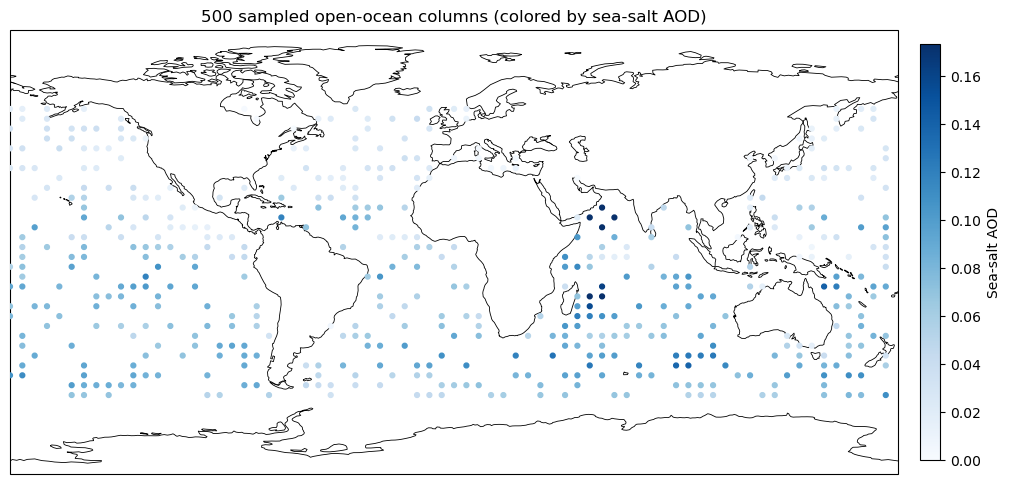

In [8]:
# generate 500 sample columns over the ocean and save them as netcdf
from cartopy.io import shapereader
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

N_SAMPLES = 500
SEED = 20260915
OUT_NC = OUT_DIR / "geoschem_ocean_columns_n500.nc"
LAT_MIN, LAT_MAX = -60, 60

# Ocean mask from Natural Earth land polygons (110 m).
land_shp = shapereader.natural_earth(resolution="110m", category="physical", name="land")
land = prep(unary_union(list(shapereader.Reader(land_shp).geometries())))
is_ocean = np.zeros_like(tau_ref, dtype=bool)
for i in range(lat.size):
    if not (LAT_MIN <= lat[i] <= LAT_MAX):
        continue
    for j in range(lon.size):
        is_ocean[i, j] = not land.contains(Point(float(lon[j]), float(lat[i])))

ocean_idx = np.argwhere(is_ocean)  # (n_ocean, 2) -> (i_lat, i_lon)
print(f"Ocean grid cells in [{LAT_MIN}, {LAT_MAX}] deg: {len(ocean_idx)} / {tau_ref.size}")

rng = np.random.default_rng(SEED)
# Prefer ocean columns with some sea salt (still open-ocean).
cand = ocean_idx[ss_col[ocean_idx[:, 0], ocean_idx[:, 1]] > 1e-4]
if len(cand) < N_SAMPLES:
    cand = ocean_idx
choice = rng.choice(len(cand), size=N_SAMPLES, replace=False)
picks = cand[choice]  # (N, 2)

# Species to store in the ocean-column NetCDF (layer AOD + dry/wet radii).
STORE_AOD = [
    "AODHyg550nm_SO4",
    "AODHyg550nm_SALA",
    "AODHyg550nm_SALC",
    "AODHyg550nm_OCPI",
    "AODHyg550nm_BCPI",
    "AODDust",
    "AODDust550nm_bin1",
    "AODDust550nm_bin2",
    "AODDust550nm_bin3",
    "AODDust550nm_bin4",
    "AODDust550nm_bin5",
    "AODDust550nm_bin6",
    "AODDust550nm_bin7",
    "AODSOAfromAqIsoprene550nm",
]
STORE_RADII = [  # GEOS-Chem radius vars (cm in source file)
    "Chem_AeroRadiSULF", "Chem_WetAeroRadiSULF",       # SO4
    "Chem_AeroRadiSSA",  "Chem_WetAeroRadiSSA",        # SALA
    "Chem_AeroRadiSSC",  "Chem_WetAeroRadiSSC",        # SALC
    "Chem_AeroRadiOC",   "Chem_WetAeroRadiOC",         # OCPI
    "Chem_AeroRadiBC",   "Chem_WetAeroRadiBC",         # BCPI
    "Chem_AeroRadiMDUST1", "Chem_WetAeroRadiMDUST1",
    "Chem_AeroRadiMDUST2", "Chem_WetAeroRadiMDUST2",
    "Chem_AeroRadiMDUST3", "Chem_WetAeroRadiMDUST3",
    "Chem_AeroRadiMDUST4", "Chem_WetAeroRadiMDUST4",
    "Chem_AeroRadiMDUST5", "Chem_WetAeroRadiMDUST5",
    "Chem_AeroRadiMDUST6", "Chem_WetAeroRadiMDUST6",
    "Chem_AeroRadiMDUST7", "Chem_WetAeroRadiMDUST7",
]

# Reload requested layer fields from the source GEOS-Chem file.
with nc.Dataset(NC_PATH) as ds_src:
    aod_layer = {name: np.asarray(ds_src[name][0], dtype=float) for name in STORE_AOD}
    radi_layer = {
        name: np.asarray(ds_src[name][0], dtype=float) * 1e4  # cm -> um
        for name in STORE_RADII
    }

n_lev = lev.size
i_lat = picks[:, 0].astype(np.int32)
i_lon = picks[:, 1].astype(np.int32)
lat_s = lat[i_lat]
lon_s = lon[i_lon]

def gather_profile(field3d):
    """field3d: (lev, lat, lon) -> (lev, sample)."""
    out = np.empty((n_lev, N_SAMPLES), dtype=np.float32)
    for k, (ii, jj) in enumerate(zip(i_lat, i_lon)):
        out[:, k] = field3d[:, ii, jj]
    return out

aod_s = {name: gather_profile(arr) for name, arr in aod_layer.items()}
radi_s = {name: gather_profile(arr) for name, arr in radi_layer.items()}
sala_s = aod_s["AODHyg550nm_SALA"]
salc_s = aod_s["AODHyg550nm_SALC"]
ss_s = sala_s + salc_s
tau_layer_s = gather_profile(tau_layer)

tau_ref_s = tau_ref[i_lat, i_lon].astype(np.float32)
ss_col_s = ss_col[i_lat, i_lon].astype(np.float32)
ratio_s = np.divide(
    ss_col_s, tau_ref_s,
    out=np.full(N_SAMPLES, np.nan, dtype=np.float32),
    where=tau_ref_s > 0,
)

if OUT_NC.exists():
    OUT_NC.unlink()
ds_out = nc.Dataset(OUT_NC, "w")
ds_out.createDimension("sample", N_SAMPLES)
ds_out.createDimension("lev", n_lev)

def put(name, data, dims, **attrs):
    arr = np.asarray(data)
    dtype = np.int32 if arr.dtype == np.int32 else np.float32
    v = ds_out.createVariable(name, dtype, dims)
    v[:] = arr
    for k, val in attrs.items():
        v.setncattr(k, val)
    return v

put("lat", lat_s, ("sample",), units="degrees_north", long_name="latitude")
put("lon", lon_s, ("sample",), units="degrees_east", long_name="longitude")
put("i_lat", i_lat, ("sample",), long_name="GEOS-Chem latitude index")
put("i_lon", i_lon, ("sample",), long_name="GEOS-Chem longitude index")
put("lev", lev.astype(np.float32), ("lev",), units="1",
    long_name="hybrid level at midpoints ((A/P0)+B)")
put("p_mid", p_mid.astype(np.float32), ("lev",), units="hPa",
    long_name="approx mid-layer pressure with PS=P0")
put("hyam", hyam.astype(np.float32), ("lev",), units="hPa")
put("hybm", hybm.astype(np.float32), ("lev",), units="1")

put("tau_ref", tau_ref_s, ("sample",), units="1",
    long_name="column total AOD at 550 nm = sum(layer AOD)")
put("ss_col", ss_col_s, ("sample",), units="1",
    long_name="column sea-salt AOD (SALA+SALC) at 550 nm")
put("ss_fraction", ratio_s, ("sample",), units="1",
    long_name="ss_col / tau_ref")

# All requested species AODs (SO4, SALA, SALC, OCPI, BCPI, dust total + bins 1-7, SOA).
for name, arr in aod_s.items():
    put(name, arr, ("lev", "sample"), units="1",
        long_name=f"layer AOD {name}")
put("AOD_seasalt", ss_s, ("lev", "sample"), units="1",
    long_name="layer AOD SALA+SALC")
put("AOD_total_layer", tau_layer_s, ("lev", "sample"), units="1",
    long_name="layer total tropospheric AOD at 550 nm")

# Matching dry/wet radii (um) for SO4, SALA/SALC, OC, BC, dust bins.
for name, arr in radi_s.items():
    put(name, arr, ("lev", "sample"), units="um",
        long_name=f"aerosol radius {name} (converted cm->um)")

ds_out.title = "GEOS-Chem open-ocean aerosol columns for RT"
ds_out.source = str(NC_PATH)
ds_out.n_samples = np.int32(N_SAMPLES)
ds_out.seed = np.int32(SEED)
ds_out.ocean_mask = "Natural Earth land 110m; points not in land polygons"
ds_out.lat_min = np.float32(LAT_MIN)
ds_out.lat_max = np.float32(LAT_MAX)
ds_out.aod_species = ",".join(STORE_AOD)
ds_out.radius_vars = ",".join(STORE_RADII)
ds_out.history = "Sampled from GEOSChem.Aerosols.20190601_0000z.nc4"
ds_out.close()
print(f"Wrote {OUT_NC}")
print(f"  stored AOD vars: {len(STORE_AOD)}")
print(f"  stored radius vars: {len(STORE_RADII)}")
print(f"  tau_ref: {tau_ref_s.min():.3f} .. {tau_ref_s.max():.3f}")
print(f"  ss_col:  {ss_col_s.min():.3f} .. {ss_col_s.max():.3f}")
print(f"  ss_frac: {np.nanmin(ratio_s):.3f} .. {np.nanmax(ratio_s):.3f}")

# Quick map of sampled locations
fig = plt.figure(figsize=(11, 5.2))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines(linewidth=0.6)
sc = ax.scatter(
    lon_s, lat_s, c=ss_col_s, s=12, cmap="Blues",
    transform=ccrs.PlateCarree(), vmin=0, vmax=np.percentile(ss_col_s, 99), zorder=3,
)
ax.set_global()
ax.set_title(f"{N_SAMPLES} sampled open-ocean columns (colored by sea-salt AOD)")
fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85, label="Sea-salt AOD")
fig.tight_layout()
map_out = OUT_DIR / "geoschem_ocean_columns_sites.png"
fig.savefig(map_out, dpi=150, bbox_inches="tight")
print("Wrote", map_out)
plt.show()